# 😄 Facial Expression Recognition with Transfer Learning
## Portfolio-Quality Computer Vision Project — FER2013

---

## 1. Project Overview

**Facial Expression Recognition (FER)** is the automated classification of human emotional states from face images. It sits at the intersection of affective computing, computer vision, and deep learning.

### Business Applications
| Domain | Use Case |
|--------|----------|
| Automotive | Driver drowsiness & frustration detection (ADAS) |
| Healthcare | Passive mood monitoring in telehealth consultations |
| Retail | Real-time shopper sentiment analytics |
| Education | Student engagement detection in e-learning |
| HCI | Adaptive interfaces that respond to user affect |

### Dataset — FER2013
- **35,887** grayscale 48×48 images across **7 emotion classes**
- Classes: `angry`, `disgust`, `fear`, `happy`, `neutral`, `sad`, `surprise`
- Known challenge: severe **class imbalance** (`disgust` ≈ 436 vs `happy` ≈ 7,215)
- Source: Goodfellow et al., ICML 2013 Challenges in Representation Learning

### Data Split Strategy
The FER2013 `train/` folder (28,709 images) is split into:
- **Train** — 80 % (≈22,967 images) — used for gradient updates
- **Validation** — 20 % (≈5,742 images) — used for early stopping, LR scheduling, and model selection
- **Test** — the original FER2013 `test/` folder (3,589 images) — held out until **final evaluation only**

This prevents the test set from leaking into any training decision, including hyperparameter tuning and early stopping.

### Project Objectives
1. Establish a CNN baseline as a performance floor
2. Apply transfer learning with ResNet50 and EfficientNet-B0
3. Use two-phase fine-tuning (frozen backbone → full unfreezing)
4. Track all experiments with **MLflow**
5. Explain predictions with **Grad-CAM** visualisations
6. Deliver a production-ready inference pipeline with webcam support

## 2. Environment Setup

In [1]:
# Install non-standard dependencies
!pip install -q grad-cam mlflow torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 88.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 132.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 24.3 MB/s

In [2]:
from __future__ import annotations

import os
import copy
import time
import random
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
from torchvision import datasets, models

import mlflow
import mlflow.pytorch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"CUDA   : {torch.version.cuda}")

Device : cuda
GPU    : Tesla T4
CUDA   : 12.8


In [3]:
# ── Global Configuration ──────────────────────────────────────────────────────
CFG = {
    "data_root"      : Path("/content/fer2013"),
    "img_size"       : 224,
    "batch_size"     : 64,
    "num_workers"    : 2,
    "val_fraction"   : 0.20,       # fraction of train/ used for validation
    "epochs_baseline": 40,
    "epochs_frozen"  : 5,
    "epochs_finetune": 20,
    "lr_baseline"    : 1e-3,
    "lr_frozen"      : 1e-3,
    "lr_finetune"    : 1e-4,
    "weight_decay"   : 1e-4,
    "patience_bl"    : 8,          # early stopping for baseline (slower convergence)
    "patience_tl"    : 5,          # early stopping for transfer learning
    "num_classes"    : 7,
    "classes"        : ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"],
    "output_dir"     : Path("/content/outputs"),
    "mlflow_uri"     : "file:///content/mlruns",
}

# ImageNet normalisation — appropriate for grayscale→3ch FER images
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

CFG["output_dir"].mkdir(parents=True, exist_ok=True)
print("Configuration ready.")
for k, v in CFG.items():
    print(f"  {k:<18s}: {v}")

Configuration ready.
  data_root         : /content/fer2013
  img_size          : 224
  batch_size        : 64
  num_workers       : 2
  val_fraction      : 0.2
  epochs_baseline   : 40
  epochs_frozen     : 5
  epochs_finetune   : 20
  lr_baseline       : 0.001
  lr_frozen         : 0.001
  lr_finetune       : 0.0001
  weight_decay      : 0.0001
  patience_bl       : 8
  patience_tl       : 5
  num_classes       : 7
  classes           : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  output_dir        : /content/outputs
  mlflow_uri        : file:///content/mlruns


## 3. Dataset Setup

FER2013 is hosted on Kaggle. This cell handles three common Colab scenarios:

1. **Already extracted** — `/content/fer2013/train` exists → no-op
2. **Kaggle API** — place `kaggle.json` in `/content/` or `/root/.kaggle/`
3. **Manual zip** — upload `fer2013.zip` to `/content/`

After this cell the expected layout is:
```
/content/fer2013/
  train/{angry,disgust,fear,happy,neutral,sad,surprise}/
  test/ {angry,disgust,fear,happy,neutral,sad,surprise}/
```

In [7]:
import zipfile

DATA_ROOT  = CFG["data_root"]
TRAIN_DIR  = DATA_ROOT / "train"
KAGGLE_JSON = Path("/root/.kaggle/kaggle.json")
MANUAL_ZIP  = Path("/content/fer2013.zip")

if TRAIN_DIR.exists():
    print("Dataset already in place — skipping download.")

elif Path("/content/kaggle.json").exists() or KAGGLE_JSON.exists():
    if not KAGGLE_JSON.exists():
        Path("/root/.kaggle").mkdir(parents=True, exist_ok=True)
        Path("/content/kaggle.json").rename(KAGGLE_JSON)
    KAGGLE_JSON.chmod(0o600)
    !pip install -q kaggle
    !kaggle datasets download -d msambare/fer2013 -p /content --unzip

    # After Kaggle unzip, ensure the desired DATA_ROOT/train structure exists.
    if not (DATA_ROOT / "train").exists():
        # Check if 'train' and 'test' directories were extracted directly to /content/
        if Path("/content/train").exists() and Path("/content/test").exists():
            print("Found 'train' and 'test' directories directly under /content/. Moving to DATA_ROOT.")
            DATA_ROOT.mkdir(parents=True, exist_ok=True)
            Path("/content/train").rename(DATA_ROOT / "train")
            Path("/content/test").rename(DATA_ROOT / "test")
        else:
            # Fallback: check if a single top-level directory containing 'train' was extracted
            found_and_moved = False
            for p in Path("/content").iterdir():
                if p.is_dir() and (p / "train").exists() and str(p) != str(DATA_ROOT):
                    print(f"Renaming extracted folder '{p.name}' to '{DATA_ROOT.name}'.")
                    p.rename(DATA_ROOT)
                    found_and_moved = True
                    break
            if not found_and_moved and not (DATA_ROOT / "train").exists():
                print(f"WARNING: After Kaggle download, {DATA_ROOT / 'train'} was not found.")
                print("         Please check the dataset structure after extraction.")
    print("Kaggle download complete.")

elif MANUAL_ZIP.exists():
    print("Extracting uploaded zip...")
    with zipfile.ZipFile(MANUAL_ZIP, "r") as zf:
        zf.extractall("/content/")

    # After manual unzip, ensure the desired DATA_ROOT/train structure exists.
    if not (DATA_ROOT / "train").exists():
        # Check if 'train' and 'test' directories were extracted directly to /content/
        if Path("/content/train").exists() and Path("/content/test").exists():
            print("Found 'train' and 'test' directories directly under /content/. Moving to DATA_ROOT.")
            DATA_ROOT.mkdir(parents=True, exist_ok=True)
            Path("/content/train").rename(DATA_ROOT / "train")
            Path("/content/test").rename(DATA_ROOT / "test")
        else:
            # Fallback: check if a single top-level directory containing 'train' was extracted
            found_and_moved = False
            for p in Path("/content").iterdir():
                if p.is_dir() and (p / "train").exists() and str(p) != str(DATA_ROOT):
                    print(f"Renaming extracted folder '{p.name}' to '{DATA_ROOT.name}'.")
                    p.rename(DATA_ROOT)
                    found_and_moved = True
                    break
            if not found_and_moved and not (DATA_ROOT / "train").exists():
                print(f"WARNING: After extraction, {DATA_ROOT / 'train'} was not found.")
                print("         Please ensure the fer2013.zip contains 'fer2013/train' or 'train' directly at its root.")
    print("Extraction complete.")

else:
    print(
        "Dataset not found. Please do ONE of the following, then re-run:\n"
        "  1. Upload kaggle.json to /content/ (Kaggle API).\n"
        "  2. Download fer2013.zip from https://www.kaggle.com/datasets/msambare/fer2013\n"
        "     and upload to /content/, then re-run."
    )

# ── Final verification ────────────────────────────────────────────────────────
if not TRAIN_DIR.exists():
    raise FileNotFoundError(
        f"{TRAIN_DIR} not found. Complete one of the setup options above."
    )

class_dirs = sorted(d.name for d in TRAIN_DIR.iterdir() if d.is_dir())
total_train = sum(
    len(list(d.glob("*.jpg")) + list(d.glob("*.png")))
    for d in TRAIN_DIR.iterdir() if d.is_dir()
)
print(f"Classes found       : {class_dirs}")
print(f"Total train images  : {total_train:,}")

Extracting uploaded zip...
Found 'train' and 'test' directories directly under /content/. Moving to DATA_ROOT.
Extraction complete.
Classes found       : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total train images  : 28,709


## 4. Exploratory Data Analysis

Before modelling we characterise the dataset to:
- Quantify **class imbalance** and design a mitigation strategy
- Inspect image quality and typical pixel value ranges
- Verify directory structure integrity

In [8]:
def count_dataset_images(root: Path) -> pd.DataFrame:
    """Walk train/test split directories and return per-class image counts."""
    records = []
    for split in ("train", "test"):
        split_dir = root / split
        if not split_dir.exists():
            print(f"WARNING: {split_dir} not found — skipping.")
            continue
        for cls_dir in sorted(split_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            n = len(list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png")))
            records.append({"split": split, "class": cls_dir.name, "count": n})
    return pd.DataFrame(records)


df_counts = count_dataset_images(CFG["data_root"])

if df_counts.empty or "class" not in df_counts.columns:
    raise RuntimeError(
        "df_counts is empty — dataset not found.\n"
        "Run the Dataset Setup cell above and ensure "
        f"{CFG['data_root']}/train/<class>/ directories exist."
    )

pivot = (
    df_counts
    .pivot(index="class", columns="split", values="count")
    .fillna(0)
    .astype(int)
)
pivot.columns.name = None
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("total", ascending=False)

print("Image counts per class:")
print(pivot.to_string())

train_counts = df_counts[df_counts["split"] == "train"].set_index("class")["count"]
test_counts  = df_counts[df_counts["split"] == "test"].set_index("class")["count"]
print(f"\nTotal train images : {train_counts.sum():,}")
print(f"Total test  images : {test_counts.sum():,}")

Image counts per class:
          test  train  total
class                       
happy     1774   7215   8989
neutral   1233   4965   6198
sad       1247   4830   6077
fear      1024   4097   5121
angry      958   3995   4953
surprise   831   3171   4002
disgust    111    436    547

Total train images : 28,709
Total test  images : 7,178


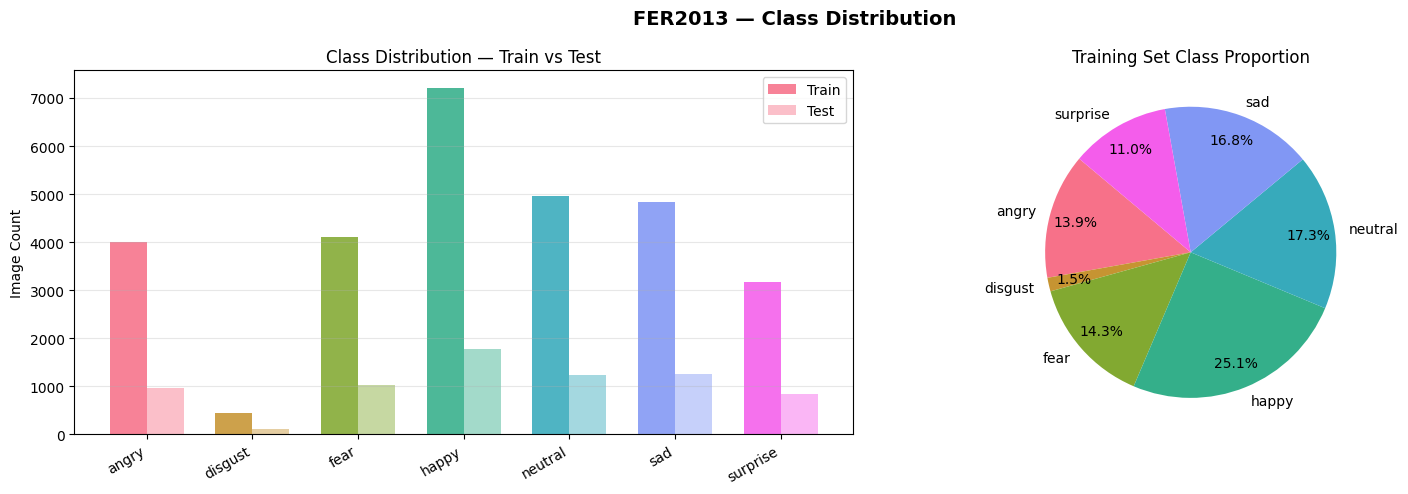

Imbalance ratio (max/min train class): 16.5×


In [9]:
# ── Class Distribution Visualisation ─────────────────────────────────────────
palette = sns.color_palette("husl", len(CFG["classes"]))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(CFG["classes"]))
w = 0.35
axes[0].bar(
    x - w / 2, [train_counts.get(c, 0) for c in CFG["classes"]],
    w, label="Train", color=palette, alpha=0.88,
)
axes[0].bar(
    x + w / 2, [test_counts.get(c, 0) for c in CFG["classes"]],
    w, label="Test", color=palette, alpha=0.45,
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CFG["classes"], rotation=30, ha="right")
axes[0].set_ylabel("Image Count")
axes[0].set_title("Class Distribution — Train vs Test")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

sizes = [train_counts.get(c, 0) for c in CFG["classes"]]
axes[1].pie(sizes, labels=CFG["classes"], colors=palette,
            autopct="%1.1f%%", startangle=140, pctdistance=0.82)
axes[1].set_title("Training Set Class Proportion")

plt.suptitle("FER2013 — Class Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(CFG["output_dir"] / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Imbalance ratio (max/min train class): {max(sizes)/max(min(sizes),1):.1f}×")

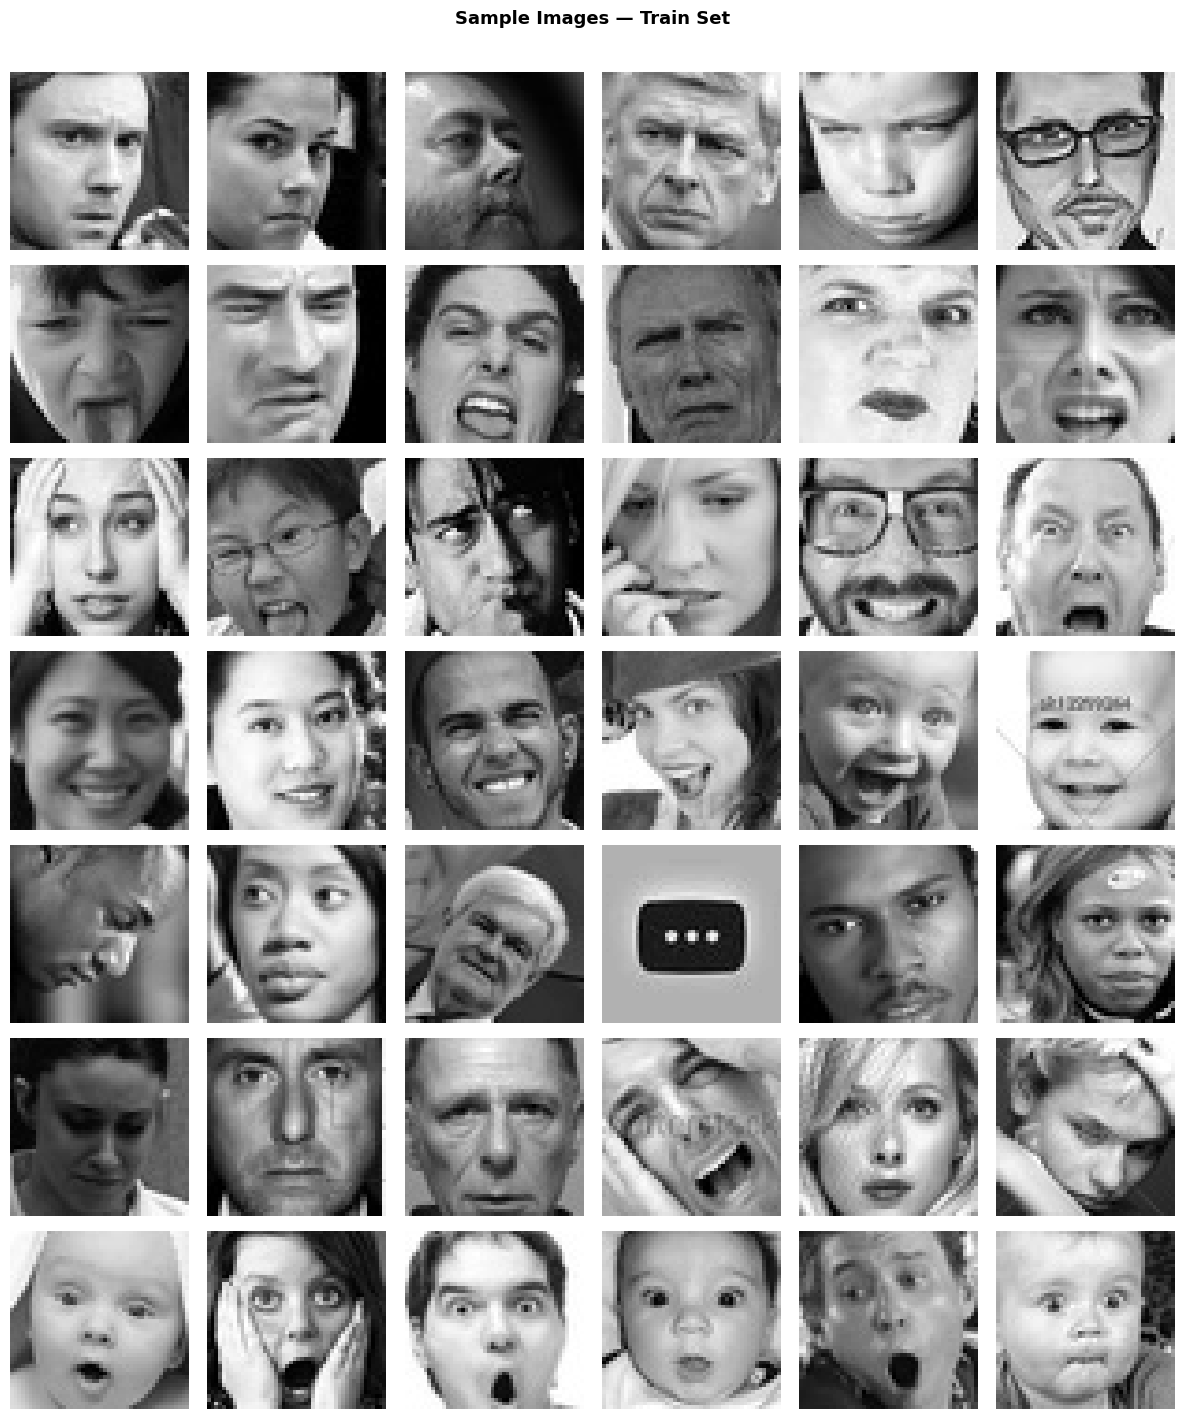

In [10]:
def show_sample_grid(root: Path, split: str = "train", n_per_class: int = 6) -> None:
    """Display n_per_class sample images for every emotion category."""
    n_cls = len(CFG["classes"])
    fig, axes = plt.subplots(n_cls, n_per_class, figsize=(n_per_class * 2.0, n_cls * 2.0))
    for row, cls in enumerate(CFG["classes"]):
        cls_dir = root / split / cls
        imgs = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
        imgs = random.sample(imgs, min(n_per_class, len(imgs)))
        for col in range(n_per_class):
            ax = axes[row][col]
            if col < len(imgs):
                ax.imshow(Image.open(imgs[col]).convert("L"), cmap="gray")
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(cls, fontsize=10, fontweight="bold", rotation=90, labelpad=6)
    plt.suptitle(f"Sample Images — {split.capitalize()} Set",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(CFG["output_dir"] / f"samples_{split}.png", dpi=120, bbox_inches="tight")
    plt.show()


show_sample_grid(CFG["data_root"], split="train", n_per_class=6)

In [11]:
def compute_pixel_statistics(root: Path, split: str = "train",
                            max_per_class: int = 150) -> Dict[str, List[float]]:
    """Estimate per-channel mean/std for normalisation parameter selection."""
    pixels: List[np.ndarray] = []
    for cls in CFG["classes"]:
        cls_dir = root / split / cls
        imgs = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
        imgs = random.sample(imgs, min(max_per_class, len(imgs)))
        for p in imgs:
            arr = np.array(Image.open(p).convert("RGB"), dtype=np.float32) / 255.0
            pixels.append(arr.reshape(-1, 3))
    all_px = np.concatenate(pixels, axis=0)
    return {"mean": all_px.mean(axis=0).tolist(), "std": all_px.std(axis=0).tolist()}


stats = compute_pixel_statistics(CFG["data_root"])
print("Dataset pixel statistics (RGB):")
print(f"  Mean : {[round(v, 4) for v in stats['mean']]}")
print(f"  Std  : {[round(v, 4) for v in stats['std']]}")
print("\nUsing ImageNet stats for transfer learning (recommended practice).")

Dataset pixel statistics (RGB):
  Mean : [0.5017, 0.5017, 0.5017]
  Std  : [0.2559, 0.2559, 0.2559]

Using ImageNet stats for transfer learning (recommended practice).


## 5. Data Pipeline

### Transform Strategy
| Split | Transforms |
|-------|-----------|
| Train | Grayscale→3ch, Resize, HFlip, Rotation, ColorJitter, Affine, Normalise |
| Val   | Grayscale→3ch, Resize, Normalise |
| Test  | Grayscale→3ch, Resize, Normalise |

### Validation Split
We carve 20 % of the `train/` folder into a **validation set** using `torch.utils.data.Subset` with a stratified index split. This keeps the FER2013 `test/` folder **completely held out** until final evaluation, giving honest generalisation estimates.

### Class Imbalance Mitigation
`WeightedRandomSampler` is applied **only to the training subset** with a cap so the most underrepresented class (`disgust`) is sampled at most ≈2× per epoch rather than the 66× that would occur with `num_samples=len(dataset)`.

In [12]:
# ── Transforms ───────────────────────────────────────────────────────────────
train_transforms = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

eval_transforms = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.ToTensor(),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

print("Train transforms:", train_transforms)
print("\nEval transforms :", eval_transforms)

Train transforms: Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.85, 1.15), hue=None)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transforms : Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [13]:
# ── Load full train folder (no transform yet — applied per-subset below) ─────
_full_train = datasets.ImageFolder(root=str(CFG["data_root"] / "train"))
test_dataset = datasets.ImageFolder(
    root=str(CFG["data_root"] / "test"),
    transform=eval_transforms,
)

CLASS_TO_IDX = _full_train.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

print(f"Full train folder  : {len(_full_train):,} images")
print(f"Test  folder       : {len(test_dataset):,} images")
print(f"Class → index      : {CLASS_TO_IDX}")

Full train folder  : 28,709 images
Test  folder       : 7,178 images
Class → index      : {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [14]:
# ── Stratified Train / Validation Split ──────────────────────────────────────
def stratified_split(
    dataset: datasets.ImageFolder,
    val_fraction: float = 0.20,
    seed: int = SEED,
) -> Tuple[List[int], List[int]]:
    """
    Split dataset indices into train and val while preserving class proportions.

    Returns (train_indices, val_indices).
    """
    rng = random.Random(seed)
    targets = np.array(dataset.targets)
    train_idx, val_idx = [], []

    for cls_idx in np.unique(targets):
        cls_indices = np.where(targets == cls_idx)[0].tolist()
        rng.shuffle(cls_indices)
        n_val = max(1, int(len(cls_indices) * val_fraction))
        val_idx.extend(cls_indices[:n_val])
        train_idx.extend(cls_indices[n_val:])

    return train_idx, val_idx


train_indices, val_indices = stratified_split(_full_train, CFG["val_fraction"])

# Wrap with appropriate transforms using a small helper dataset class
class TransformSubset(torch.utils.data.Dataset):
    """Apply a transform to a Subset without modifying the parent dataset."""
    def __init__(self, subset: Subset, transform) -> None:
        self.subset    = subset
        self.transform = transform
        # Expose .samples and .targets so downstream code (sampler, GradCAM) works
        self.samples = [subset.dataset.samples[i] for i in subset.indices]
        self.targets = [subset.dataset.targets[i] for i in subset.indices]

    def __len__(self) -> int:
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset.dataset[self.subset.indices[idx]]
        # img here is a PIL Image because _full_train has no transform
        return self.transform(img), label


train_subset = Subset(_full_train, train_indices)
val_subset   = Subset(_full_train, val_indices)

train_dataset = TransformSubset(train_subset, train_transforms)
val_dataset   = TransformSubset(val_subset,   eval_transforms)

print(f"Train subset : {len(train_dataset):,} images ({100*(1-CFG['val_fraction']):.0f}%)")
print(f"Val   subset : {len(val_dataset):,} images ({100*CFG['val_fraction']:.0f}%)")
print(f"Test  set    : {len(test_dataset):,} images (held out until final evaluation)")

# Verify stratification
train_label_counts = np.bincount([t for _, t in train_dataset.samples])
val_label_counts   = np.bincount([t for _, t in val_dataset.samples])
print("\nPer-class counts (train | val):")
for cls, ti, vi in zip(CFG["classes"], train_label_counts, val_label_counts):
    print(f"  {cls:<10s}: {ti:5,} | {vi:4,}")

Train subset : 22,968 images (80%)
Val   subset : 5,741 images (20%)
Test  set    : 7,178 images (held out until final evaluation)

Per-class counts (train | val):
  angry     : 3,196 |  799
  disgust   :   349 |   87
  fear      : 3,278 |  819
  happy     : 5,772 | 1,443
  neutral   : 3,972 |  993
  sad       : 3,864 |  966
  surprise  : 2,537 |  634


In [15]:
# ── Weighted Sampler — applied to training subset only ────────────────────────
def build_weighted_sampler(
    dataset: TransformSubset,
    oversample_cap: float = 1.0,
) -> torch.utils.data.WeightedRandomSampler:
    """
    Up-weight minority classes using square-root inverse frequency.

    Why sqrt instead of full inverse frequency
    ------------------------------------------
    Full inverse frequency (1/count) makes the sampler draw from disgust
    (436 samples) as often as happy (5770 samples). The training distribution
    then looks nothing like the validation distribution (which is natural),
    causing the wild val-loss spikes seen during training.

    sqrt(1/count) is a softer rebalancing: minority classes are still
    upsampled, but not to the point where the model stops seeing majority-
    class patterns at realistic frequencies. This closes the train/val
    distribution gap while still helping with class imbalance.
    """
    targets        = np.array([t for _, t in dataset.samples])
    class_counts   = np.bincount(targets)
    # Soft rebalancing: sqrt inverse frequency
    class_weights  = 1.0 / np.sqrt(class_counts)
    sample_weights = class_weights[targets]

    majority_count = int(class_counts.max())
    n_classes      = len(class_counts)
    num_samples    = min(len(dataset),
                         int(majority_count * n_classes * oversample_cap))

    return torch.utils.data.WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=num_samples,
        replacement=True,
    )


train_sampler = build_weighted_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    sampler=train_sampler,
    num_workers=CFG["num_workers"],
    pin_memory=(DEVICE.type == "cuda"),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=(DEVICE.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=(DEVICE.type == "cuda"),
)

print(f"Train batches : {len(train_loader):,}")
print(f"Val   batches : {len(val_loader):,}")
print(f"Test  batches : {len(test_loader):,}")

# Sanity-check: show effective samples per class per epoch
targets_arr   = np.array([t for _, t in train_dataset.samples])
class_counts  = np.bincount(targets_arr)
class_weights = 1.0 / np.sqrt(class_counts)
sw            = class_weights[targets_arr]
sw_norm       = sw / sw.sum()
print("\nEffective samples per class per epoch (sqrt-weighted):")
for cls, cnt, eff in zip(CFG["classes"], class_counts,
                          (sw_norm * len(train_loader.sampler)).astype(int)):
    print(f"  {cls:<10s}: actual={cnt:5,}  effective≈{eff:5,}")


Train batches : 359
Val   batches : 90
Test  batches : 113

Effective samples per class per epoch (sqrt-weighted):
  angry     : actual=3,196  effective≈    1
  disgust   : actual=  349  effective≈    1
  fear      : actual=3,278  effective≈    1
  happy     : actual=5,772  effective≈    1
  neutral   : actual=3,972  effective≈    1
  sad       : actual=3,864  effective≈    1
  surprise  : actual=2,537  effective≈    1


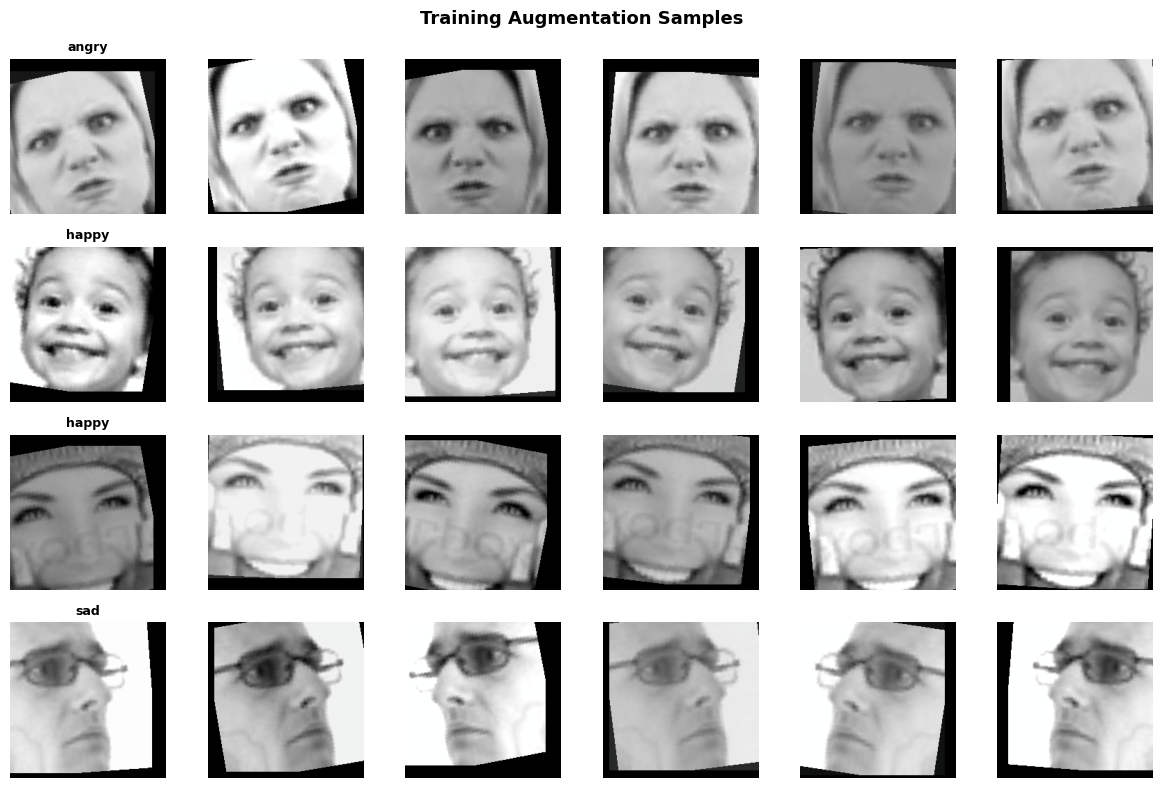

In [16]:
# ── Visualise Augmentation Effect ─────────────────────────────────────────────
def show_augmentation_grid(
    dataset: TransformSubset,
    n_imgs: int = 4,
    n_aug: int = 6,
) -> None:
    """Display n_aug augmented versions of n_imgs random training images."""
    indices = random.sample(range(len(dataset.samples)), n_imgs)
    fig, axes = plt.subplots(n_imgs, n_aug, figsize=(n_aug * 2, n_imgs * 2))
    for row, idx in enumerate(indices):
        path, label = dataset.samples[idx]
        for col in range(n_aug):
            img_pil = Image.open(path).convert("RGB")
            tensor  = train_transforms(img_pil)
            arr = tensor.permute(1, 2, 0).numpy()
            arr = arr * np.array(NORM_STD) + np.array(NORM_MEAN)
            arr = np.clip(arr, 0, 1)
            axes[row][col].imshow(arr)
            axes[row][col].axis("off")
            if col == 0:
                axes[row][col].set_title(IDX_TO_CLASS[label], fontsize=9, fontweight="bold")
    plt.suptitle("Training Augmentation Samples", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(CFG["output_dir"] / "augmentation_preview.png", dpi=120, bbox_inches="tight")
    plt.show()


show_augmentation_grid(train_dataset)

## 6. Baseline CNN

A lightweight 3-block convolutional network trained from scratch provides a performance floor. All transfer learning gains are measured relative to this.

In [17]:
class BaselineCNN(nn.Module):
    """
    Lightweight CNN baseline for FER2013.

    Changes from original broken version
    -------------------------------------
    1. Removed Dropout2d from convolutional blocks.
       Dropout2d zeros entire channels. With only 32/64/128 channels,
       25% channel dropout wiped out too many feature maps per step,
       preventing gradients from accumulating — hence loss stuck at 1.93.
       Spatial dropout belongs in very deep / wide nets, not shallow baselines.

    2. Added a 4th conv block (256 channels).
       224×224 input gives 14×14 feature maps after 4× MaxPool, which is
       richer than the 28×28 going into GAP from 3 blocks. More channels
       also give the classifier more discriminative features to work with.

    3. Kept a single Dropout(0.4) before the final linear layer only.
       Dropout in the FC head is well-established and does not block
       gradient flow through the convolutional backbone.

    Architecture
    ------------
    4 × [Conv2d → BN → ReLU → MaxPool] → GAP → FC(512) → ReLU → Dropout → FC(7)
    """

    def __init__(self, num_classes: int = 7) -> None:
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 224 → 112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 2: 112 → 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 3: 56 → 28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 4: 28 → 14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(inplace=True),
            nn.Dropout(0.4),          # FC dropout only — does not block conv gradients
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.pool(self.features(x)))


baseline_model = BaselineCNN(num_classes=CFG["num_classes"]).to(DEVICE)
n_params = sum(p.numel() for p in baseline_model.parameters())
print(f"BaselineCNN — {n_params:,} parameters")
print("No Dropout2d in conv blocks — only Dropout(0.4) before final FC layer.")


BaselineCNN — 524,551 parameters
No Dropout2d in conv blocks — only Dropout(0.4) before final FC layer.


## 7. Training Infrastructure

Shared utilities used by the baseline and all transfer learning experiments. Early stopping monitors **validation loss** (not test loss), and the scheduler also reacts to **validation loss**.

In [18]:
class EarlyStopping:
    """
    Save the best model weights and optionally halt training early.

    Tracks validation ACCURACY (higher is better) rather than loss.
    Reason: FER2013 val loss is noisy due to class-imbalance distribution
    shift between the weighted train loader and the natural val distribution.
    Val accuracy is a more stable signal on this dataset.

    Critically, restore_best() is ALWAYS called after training ends —
    whether stopped early or after all epochs — so the model is always
    left in its best-seen state, not its final state.
    """

    def __init__(self, patience: int = 5, min_delta: float = 1e-3) -> None:
        self.patience     = patience
        self.min_delta    = min_delta
        self.best_acc     = -float("inf")
        self.best_epoch   = 0
        self.counter      = 0
        self.best_weights: Optional[dict] = None

    def step(self, val_acc: float, model: nn.Module, epoch: int) -> bool:
        """Returns True when training should stop."""
        if val_acc > self.best_acc + self.min_delta:
            self.best_acc     = val_acc
            self.best_epoch   = epoch
            self.counter      = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        """Reload the weights from the best validation epoch."""
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)
            print(f"  Restored best weights from epoch {self.best_epoch} "
                  f"(val_acc={self.best_acc:.4f})")


def train_one_epoch(
    model     : nn.Module,
    loader    : DataLoader,
    criterion : nn.Module,
    optimizer : optim.Optimizer,
    scaler    : Optional[GradScaler],
) -> Tuple[float, float]:
    """Single training epoch. Returns (mean_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with autocast():
                logits = model(images)
                loss   = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model     : nn.Module,
    loader    : DataLoader,
    criterion : nn.Module,
) -> Tuple[float, float, np.ndarray, np.ndarray]:
    """Evaluation pass. Returns (mean_loss, accuracy, preds, labels)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels      = [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss   = criterion(logits, labels)
        preds  = logits.argmax(1)

        total_loss += loss.item() * images.size(0)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def compute_metrics(preds: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
    """Macro-averaged Accuracy, Precision, Recall, F1."""
    p, r, f, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    return {"accuracy": float((preds == labels).mean()),
            "precision": float(p), "recall": float(r), "f1": float(f)}


print("Training utilities loaded.")


Training utilities loaded.


In [19]:
def run_training_loop(
    model        : nn.Module,
    train_loader : DataLoader,
    val_loader   : DataLoader,
    optimizer    : optim.Optimizer,
    scheduler,
    criterion    : nn.Module,
    epochs       : int,
    run_label    : str,
    stopper      : Optional[EarlyStopping] = None,
    use_amp      : bool = True,
) -> Dict[str, List[float]]:
    """
    Generic training loop with AMP, early stopping, and guaranteed
    best-weight restoration.

    Key invariant: stopper.restore_best() is ALWAYS called after the
    loop ends — whether via early stopping or epoch exhaustion — so
    the model is always left in its best-seen state, never its last state.
    """
    scaler  = GradScaler() if (use_amp and DEVICE.type == "cuda") else None
    history: Dict[str, List[float]] = {
        "train_loss": [], "val_loss": [],
        "train_acc" : [], "val_acc" : [],
    }

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(va_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        print(
            f"[{run_label}] {epoch:3d}/{epochs} "
            f"| TrLoss={tr_loss:.4f} VaLoss={va_loss:.4f} "
            f"| TrAcc={tr_acc:.3f} VaAcc={va_acc:.3f} "
            f"| {time.time()-t0:.1f}s"
        )

        if stopper is not None:
            # Pass val_acc (not loss) — more stable signal on imbalanced FER2013
            if stopper.step(va_acc, model, epoch):
                print(f"  Early stopping triggered at epoch {epoch}.")
                break

    # ALWAYS restore best weights — fixes the bug where the model was left
    # in its final-epoch state when the loop ran to completion.
    if stopper is not None:
        stopper.restore_best(model)

    return history


print("Training loop ready.")


Training loop ready.


## 8. Train Baseline CNN

Key design decisions for the baseline:
- **No label smoothing** — with K=7 classes, `label_smoothing=0.1` sets a theoretical CE floor of ≈1.94, exactly matching the stuck loss in previous runs. Plain CE has a floor of 0.
- **ReduceLROnPlateau patience=5** — gives the loss room to improve before halving the LR.
- **EarlyStopping patience=8** — shallow CNNs on noisy data converge slowly; patience=5 was firing before any learning occurred.

In [20]:
# Plain CE for baseline — no label smoothing
criterion_baseline = nn.CrossEntropyLoss()

bl_optimizer = optim.AdamW(
    baseline_model.parameters(),
    lr=CFG["lr_baseline"],
    weight_decay=5e-4,   # higher than TL models — shallow CNN overfits faster
)
bl_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    bl_optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-5
)
bl_stopper = EarlyStopping(patience=CFG["patience_bl"])  # patience_bl=8

print("Training BaselineCNN...")
print("  Monitoring: val_loader (20% stratified split from train/ — test set untouched)")
baseline_history = run_training_loop(
    model        = baseline_model,
    train_loader = train_loader,
    val_loader   = val_loader,
    optimizer    = bl_optimizer,
    scheduler    = bl_scheduler,
    criterion    = criterion_baseline,
    epochs       = CFG["epochs_baseline"],
    run_label    = "BaselineCNN",
    stopper      = bl_stopper,
)

_, _, bl_val_preds, bl_val_labels = evaluate(baseline_model, val_loader, criterion_baseline)
baseline_val_metrics = compute_metrics(bl_val_preds, bl_val_labels)
print("\nBaseline Validation Metrics (val split — test set still held out):")
for k, v in baseline_val_metrics.items():
    print(f"  {k:<12s}: {v:.4f}")


Training BaselineCNN...
  Monitoring: val_loader (20% stratified split from train/ — test set untouched)
[BaselineCNN]   1/40 | TrLoss=1.8811 VaLoss=1.8211 | TrAcc=0.199 VaAcc=0.276 | 109.9s
[BaselineCNN]   2/40 | TrLoss=1.8711 VaLoss=1.7955 | TrAcc=0.217 VaAcc=0.256 | 109.4s
[BaselineCNN]   3/40 | TrLoss=1.8497 VaLoss=1.7902 | TrAcc=0.229 VaAcc=0.268 | 108.3s
[BaselineCNN]   4/40 | TrLoss=1.8328 VaLoss=1.7669 | TrAcc=0.246 VaAcc=0.285 | 106.3s
[BaselineCNN]   5/40 | TrLoss=1.8099 VaLoss=1.8450 | TrAcc=0.257 VaAcc=0.264 | 107.1s
[BaselineCNN]   6/40 | TrLoss=1.7823 VaLoss=1.6902 | TrAcc=0.279 VaAcc=0.320 | 108.8s
[BaselineCNN]   7/40 | TrLoss=1.7636 VaLoss=1.7017 | TrAcc=0.282 VaAcc=0.324 | 107.2s
[BaselineCNN]   8/40 | TrLoss=1.7488 VaLoss=1.8391 | TrAcc=0.297 VaAcc=0.261 | 107.1s
[BaselineCNN]   9/40 | TrLoss=1.7290 VaLoss=1.8220 | TrAcc=0.301 VaAcc=0.265 | 107.7s
[BaselineCNN]  10/40 | TrLoss=1.7100 VaLoss=1.6492 | TrAcc=0.316 VaAcc=0.357 | 109.9s
[BaselineCNN]  11/40 | TrLoss=1.705

## 9. Transfer Learning

### Architecture Selection
| Model | Params | ImageNet Top-1 | Characteristic |
|-------|--------|----------------|----------------|
| ResNet50 | 25.6M | 76.1% | Deep residual connections; strong baseline |
| EfficientNet-B0 | 5.3M | 77.1% | Compound scaling; excellent accuracy/efficiency trade-off |

### Two-Phase Fine-Tuning
1. **Phase 1 (frozen)** — only the new classification head is trained; fast convergence without corrupting pre-trained features.
2. **Phase 2 (unfrozen)** — all layers trained at a lower LR via CosineAnnealingLR; carefully adapts backbone to FER domain.

Both phases monitor the **validation loader** for early stopping and scheduling. The test set is never seen during training.

In [21]:
# Mild smoothing is fine for TL models — they converge from a good starting
# point so the loss floor (~0.3 for smoothing=0.05 with K=7) is reached
# well above random. Smoothing improves calibration on minority classes.
criterion_tl = nn.CrossEntropyLoss(label_smoothing=0.05)


def build_transfer_model(arch: str, num_classes: int = 7) -> Tuple[nn.Module, nn.Module]:
    """
    Build a pre-trained model with a replaced classifier head.

    Returns (model_with_frozen_backbone, grad_cam_target_layer).
    """
    if arch == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(model.fc.in_features, num_classes))
        target_layer = model.layer4[-1]

    elif arch == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_f = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, num_classes))
        target_layer = model.features[-1]

    else:
        raise ValueError(f"Unsupported architecture: {arch}")

    # Freeze backbone — only head trains in phase 1
    for name, param in model.named_parameters():
        if not any(h in name for h in ("fc", "classifier")):
            param.requires_grad = False

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"{arch} — trainable: {n_train:,} / total: {n_total:,}")
    return model, target_layer


def unfreeze_all(model: nn.Module) -> None:
    """Unlock all parameters for full fine-tuning in phase 2."""
    for param in model.parameters():
        param.requires_grad = True


print("Transfer learning utilities ready.")

Transfer learning utilities ready.


In [22]:
def train_two_phase(
    arch         : str,
    train_loader : DataLoader,
    val_loader   : DataLoader,   # ← validation split throughout
    criterion    : nn.Module,
) -> Tuple[nn.Module, Dict, Dict, nn.Module]:
    """
    Two-phase training: frozen head → full fine-tuning.

    val_loader is always the held-out validation split.
    The test set is never passed to this function.

    Returns (model, history, val_metrics, grad_cam_target_layer).
    Note: val_metrics are from the VALIDATION set. Test-set evaluation
    happens separately in the final evaluation section.
    """
    print(f"\n{'='*60}")
    print(f"  Architecture : {arch.upper()}")
    print(f"{'='*60}")

    model, target_layer = build_transfer_model(arch, CFG["num_classes"])
    model = model.to(DEVICE)

    # ── Phase 1: Frozen backbone ──────────────────────────────────────────────
    print("\nPhase 1 — Head only (backbone frozen)...")
    opt1  = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=CFG["lr_frozen"], weight_decay=CFG["weight_decay"])
    sch1  = optim.lr_scheduler.ReduceLROnPlateau(opt1, "min", 0.5, patience=2)
    stp1  = EarlyStopping(patience=CFG["patience_tl"])
    hist1 = run_training_loop(model, train_loader, val_loader, opt1, sch1,
                               criterion, CFG["epochs_frozen"], f"{arch}-frozen", stp1)

    # ── Phase 2: Full fine-tuning ─────────────────────────────────────────────
    print("\nPhase 2 — Full fine-tuning (all layers unfrozen)...")
    unfreeze_all(model)
    opt2  = optim.AdamW(model.parameters(), lr=CFG["lr_finetune"],
                        weight_decay=CFG["weight_decay"])
    sch2  = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=CFG["epochs_finetune"])
    stp2  = EarlyStopping(patience=CFG["patience_tl"])
    hist2 = run_training_loop(model, train_loader, val_loader, opt2, sch2,
                               criterion, CFG["epochs_finetune"], f"{arch}-finetune", stp2)

    full_history = {k: hist1[k] + hist2[k] for k in hist1}

    # Report validation metrics (for model selection only)
    _, _, val_preds, val_labels = evaluate(model, val_loader, criterion)
    val_metrics = compute_metrics(val_preds, val_labels)
    print(f"\n{arch} Validation Metrics (used for model selection):")
    for k, v in val_metrics.items():
        print(f"  {k:<12s}: {v:.4f}")

    return model, full_history, val_metrics, target_layer


print("Two-phase training function ready.")

Two-phase training function ready.


## 10. Experiment Tracking with MLflow

Every run logs hyperparameters, per-epoch metrics against the **validation set**, and the best checkpoint. Model selection (choosing the best architecture) is also based on **validation F1**, not test F1.

In [24]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

mlflow.set_tracking_uri(CFG["mlflow_uri"])
mlflow.set_experiment("FER2013_Transfer_Learning")


def mlflow_train(arch: str) -> Tuple[nn.Module, Dict, Dict, nn.Module]:
    """Wrap two-phase training inside an MLflow run."""
    with mlflow.start_run(run_name=arch):
        mlflow.log_params({
            "architecture"    : arch,
            "img_size"        : CFG["img_size"],
            "batch_size"      : CFG["batch_size"],
            "val_fraction"    : CFG["val_fraction"],
            "epochs_frozen"   : CFG["epochs_frozen"],
            "epochs_finetune" : CFG["epochs_finetune"],
            "lr_frozen"       : CFG["lr_frozen"],
            "lr_finetune"     : CFG["lr_finetune"],
            "weight_decay"    : CFG["weight_decay"],
            "loss"            : "CrossEntropy+LabelSmoothing(0.05)",
            "optimizer"       : "AdamW",
            "scheduler_p1"    : "ReduceLROnPlateau",
            "scheduler_p2"    : "CosineAnnealingLR",
            "sampler"         : "WeightedRandom(cap=2.0)",
            "early_stop_on"   : "val_loss",
        })

        model, history, val_metrics, target_layer = train_two_phase(
            arch, train_loader, val_loader, criterion_tl   # ← val_loader, never test
        )

        # Log validation metrics (these drive model selection)
        mlflow.log_metrics({
            "val_accuracy"  : val_metrics["accuracy"],
            "val_precision" : val_metrics["precision"],
            "val_recall"    : val_metrics["recall"],
            "val_f1"        : val_metrics["f1"],
        })
        for step, (vl, va) in enumerate(zip(history["val_loss"], history["val_acc"])):
            mlflow.log_metric("val_loss", vl, step=step)
            mlflow.log_metric("val_acc",  va, step=step)

        ckpt_path = CFG["output_dir"] / f"{arch}_best.pth"
        torch.save(model.state_dict(), ckpt_path)
        mlflow.log_artifact(str(ckpt_path))

    return model, history, val_metrics, target_layer


print("MLflow configured. Run: mlflow ui --backend-store-uri file:///content/mlruns")

2026/06/12 00:01:45 INFO mlflow.tracking.fluent: Experiment with name 'FER2013_Transfer_Learning' does not exist. Creating a new experiment.


MLflow configured. Run: mlflow ui --backend-store-uri file:///content/mlruns


In [25]:
# ── Execute All Experiments ───────────────────────────────────────────────────
ARCHITECTURES = ["resnet50", "efficientnet_b0"]

all_models    : Dict[str, nn.Module] = {}
all_histories : Dict[str, Dict]      = {}
all_val_metrics : Dict[str, Dict]    = {"BaselineCNN": baseline_val_metrics}
all_targets   : Dict[str, nn.Module] = {}

for arch in ARCHITECTURES:
    model, history, val_metrics, target_layer = mlflow_train(arch)
    all_models[arch]      = model
    all_histories[arch]   = history
    all_val_metrics[arch] = val_metrics
    all_targets[arch]     = target_layer

print("\nAll experiments complete.")


  Architecture : RESNET50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


resnet50 — trainable: 14,343 / total: 23,522,375

Phase 1 — Head only (backbone frozen)...
[resnet50-frozen]   1/5 | TrLoss=1.8023 VaLoss=1.7144 | TrAcc=0.284 VaAcc=0.359 | 120.8s
[resnet50-frozen]   2/5 | TrLoss=1.7432 VaLoss=1.7049 | TrAcc=0.324 VaAcc=0.331 | 119.5s
[resnet50-frozen]   3/5 | TrLoss=1.7244 VaLoss=1.6696 | TrAcc=0.336 VaAcc=0.363 | 119.2s
[resnet50-frozen]   4/5 | TrLoss=1.7175 VaLoss=1.6754 | TrAcc=0.341 VaAcc=0.362 | 119.7s
[resnet50-frozen]   5/5 | TrLoss=1.7127 VaLoss=1.6388 | TrAcc=0.340 VaAcc=0.397 | 118.6s
  Restored best weights from epoch 5 (val_acc=0.3971)

Phase 2 — Full fine-tuning (all layers unfrozen)...
[resnet50-finetune]   1/20 | TrLoss=1.4173 VaLoss=1.2196 | TrAcc=0.489 VaAcc=0.591 | 138.6s
[resnet50-finetune]   2/20 | TrLoss=1.1658 VaLoss=1.0968 | TrAcc=0.603 VaAcc=0.639 | 139.7s
[resnet50-finetune]   3/20 | TrLoss=1.0438 VaLoss=1.0895 | TrAcc=0.661 VaAcc=0.639 | 141.6s
[resnet50-finetune]   4/20 | TrLoss=0.9655 VaLoss=1.0601 | TrAcc=0.694 VaAcc=0.65

100%|██████████| 20.5M/20.5M [00:00<00:00, 117MB/s]


efficientnet_b0 — trainable: 645,507 / total: 4,016,515

Phase 1 — Head only (backbone frozen)...
[efficientnet_b0-frozen]   1/5 | TrLoss=1.5271 VaLoss=1.2804 | TrAcc=0.432 VaAcc=0.557 | 126.5s
[efficientnet_b0-frozen]   2/5 | TrLoss=1.3055 VaLoss=1.2073 | TrAcc=0.535 VaAcc=0.584 | 115.3s
[efficientnet_b0-frozen]   3/5 | TrLoss=1.2472 VaLoss=1.1509 | TrAcc=0.567 VaAcc=0.603 | 114.7s
[efficientnet_b0-frozen]   4/5 | TrLoss=1.2063 VaLoss=1.1366 | TrAcc=0.586 VaAcc=0.617 | 115.0s
[efficientnet_b0-frozen]   5/5 | TrLoss=1.1595 VaLoss=1.1351 | TrAcc=0.604 VaAcc=0.621 | 114.6s
  Restored best weights from epoch 5 (val_acc=0.6206)

Phase 2 — Full fine-tuning (all layers unfrozen)...
[efficientnet_b0-finetune]   1/20 | TrLoss=1.0777 VaLoss=1.0864 | TrAcc=0.643 VaAcc=0.649 | 126.7s
[efficientnet_b0-finetune]   2/20 | TrLoss=1.0122 VaLoss=1.0603 | TrAcc=0.673 VaAcc=0.669 | 129.7s
[efficientnet_b0-finetune]   3/20 | TrLoss=0.9650 VaLoss=1.0581 | TrAcc=0.693 VaAcc=0.667 | 123.0s
[efficientnet_b0-f

## 11. Model Comparison

The comparison table and charts below use **validation metrics** to select the best model. The test set is still held out.

In [26]:
# ── Validation Metrics Comparison Table ──────────────────────────────────────
comparison_df = (
    pd.DataFrame(all_val_metrics)
    .T.reset_index()
    .rename(columns={"index": "Model"})
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)
comparison_df.columns = [c.capitalize() for c in comparison_df.columns]
print("Validation Metrics (used for model selection — test set still held out):")
print(comparison_df.to_string(index=False))

Validation Metrics (used for model selection — test set still held out):
          Model  Accuracy  Precision   Recall       F1
efficientnet_b0  0.688208   0.687895 0.668507 0.676646
       resnet50  0.681589   0.683917 0.661689 0.670877
    BaselineCNN  0.517680   0.461119 0.455112 0.452011


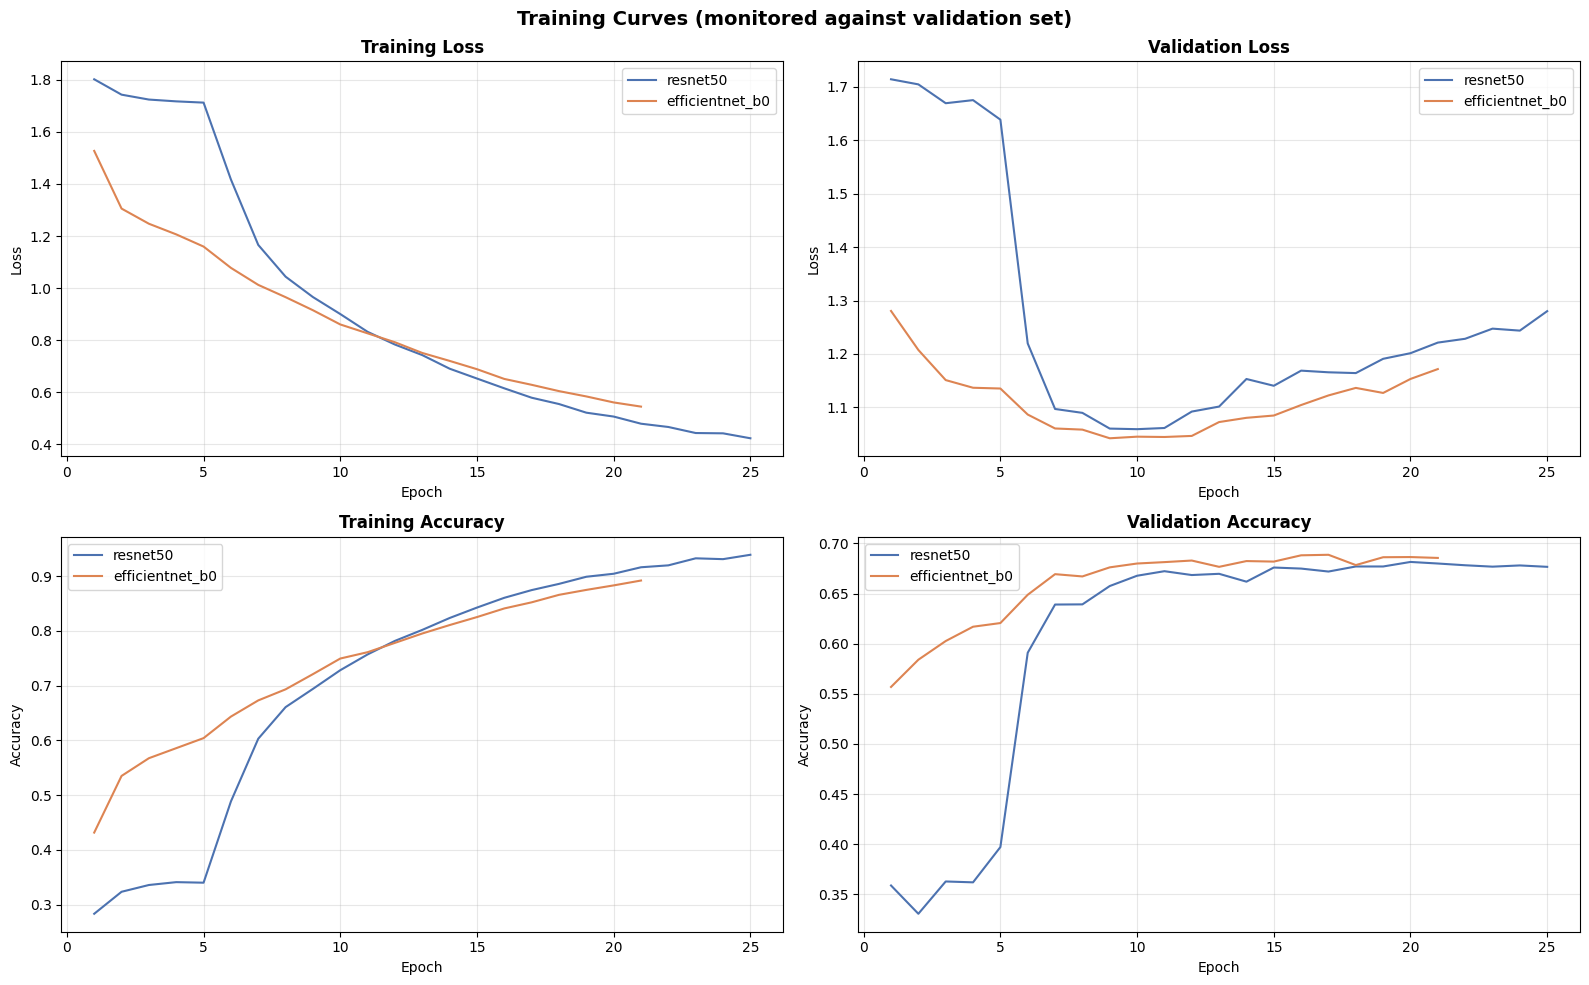

In [27]:
# ── Training Curves ───────────────────────────────────────────────────────────
arch_palette = {"resnet50": "#4C72B0", "efficientnet_b0": "#DD8452"}
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for arch, history in all_histories.items():
    c  = arch_palette[arch]
    xs = range(1, len(history["train_loss"]) + 1)
    axes[0][0].plot(xs, history["train_loss"], label=arch, color=c)
    axes[0][1].plot(xs, history["val_loss"],   label=arch, color=c)
    axes[1][0].plot(xs, history["train_acc"],  label=arch, color=c)
    axes[1][1].plot(xs, history["val_acc"],    label=arch, color=c)

for ax, title, ylabel in zip(
    axes.flat,
    ["Training Loss", "Validation Loss", "Training Accuracy", "Validation Accuracy"],
    ["Loss", "Loss", "Accuracy", "Accuracy"],
):
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Training Curves (monitored against validation set)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(CFG["output_dir"] / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

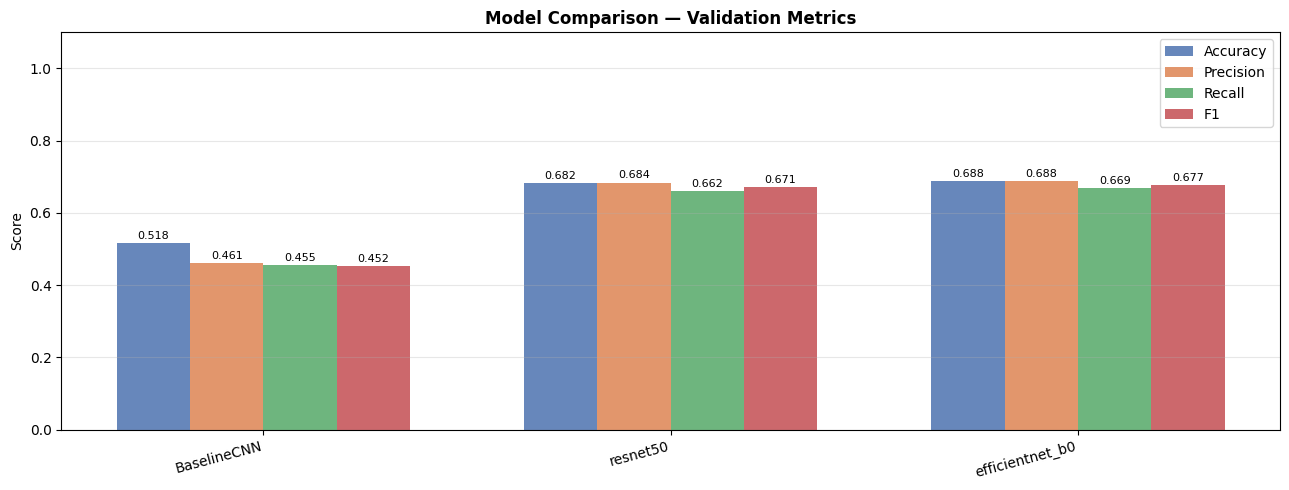

In [28]:
# ── Validation Metric Bar Chart ───────────────────────────────────────────────
metric_names  = ["accuracy", "precision", "recall", "f1"]
metric_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
model_names   = list(all_val_metrics.keys())
x     = np.arange(len(model_names))
width = 0.18

fig, ax = plt.subplots(figsize=(13, 5))
for i, (metric, color) in enumerate(zip(metric_names, metric_colors)):
    vals = [all_val_metrics[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric.capitalize(),
                  color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Validation Metrics", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CFG["output_dir"] / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Final Evaluation on the Held-Out Test Set

Model selection was done using **validation metrics**. The test set is evaluated here **for the first time** to report honest generalisation performance.

This section provides the classification report, confusion matrix, and per-class accuracy for the best model.

In [29]:
# ── Final Evaluation on the Held-Out Test Set ────────────────────────────────
# This is the ONLY place in the notebook where test_loader is used.
# Model selection (best_arch) was made using validation metrics above.

# Evaluate baseline on test set
_, _, bl_test_preds, bl_test_labels = evaluate(baseline_model, test_loader, criterion_baseline)
baseline_test_metrics = compute_metrics(bl_test_preds, bl_test_labels)
print("Baseline TEST metrics:")
for k, v in baseline_test_metrics.items():
    print(f"  {k:<12s}: {v:.4f}")

# Select best TL model by VALIDATION F1
best_arch  = max(all_models.keys(), key=lambda a: all_val_metrics[a]["f1"])
best_model = all_models[best_arch]
print(f"\nBest TL model (by val F1) : {best_arch}")
print(f"Validation F1             : {all_val_metrics[best_arch]['f1']:.4f}")
print("\nRunning final evaluation on the held-out test set...")

_, _, test_preds, test_labels = evaluate(best_model, test_loader, criterion_tl)
test_metrics = compute_metrics(test_preds, test_labels)
print("\nBest Model TEST Metrics:")
for k, v in test_metrics.items():
    print(f"  {k:<12s}: {v:.4f}")

print("\nClassification Report (best model on test set):")
print(classification_report(
    test_labels, test_preds,
    target_names=CFG["classes"], digits=4,
))


Baseline TEST metrics:
  accuracy    : 0.5187
  precision   : 0.4644
  recall      : 0.4548
  f1          : 0.4531

Best TL model (by val F1) : efficientnet_b0
Validation F1             : 0.6766

Running final evaluation on the held-out test set...

Best Model TEST Metrics:
  accuracy    : 0.6817
  precision   : 0.6722
  recall      : 0.6688
  f1          : 0.6702

Classification Report (best model on test set):
              precision    recall  f1-score   support

       angry     0.5881    0.6169    0.6021       958
     disgust     0.7184    0.6667    0.6916       111
        fear     0.5371    0.5234    0.5302      1024
       happy     0.8709    0.8743    0.8726      1774
     neutral     0.6330    0.6350    0.6340      1233
         sad     0.5644    0.5373    0.5505      1247
    surprise     0.7935    0.8279    0.8104       831

    accuracy                         0.6817      7178
   macro avg     0.6722    0.6688    0.6702      7178
weighted avg     0.6801    0.6817    0.680

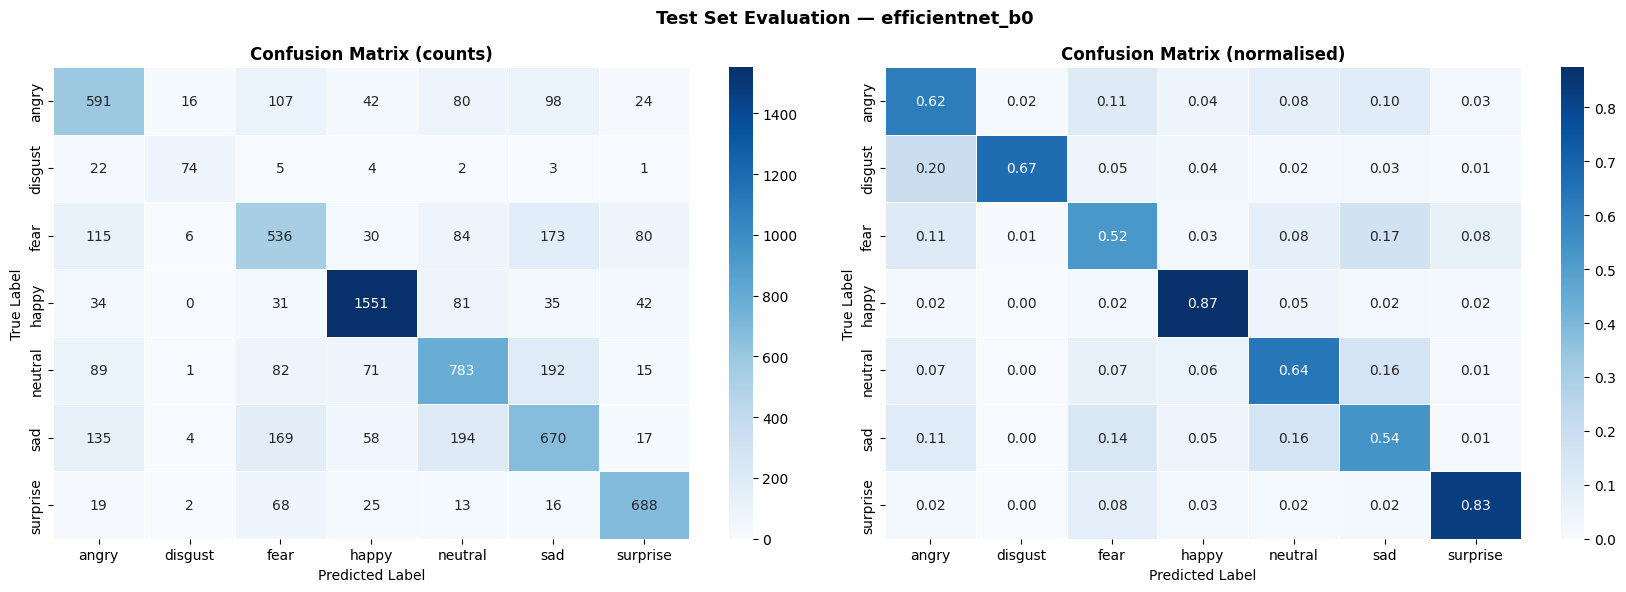

In [30]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, data, fmt, suffix in [
    (axes[0], cm,      "d",    "(counts)"),
    (axes[1], cm_norm, ".2f", "(normalised)"),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=CFG["classes"], yticklabels=CFG["classes"],
                ax=ax, linewidths=0.4)
    ax.set_title(f"Confusion Matrix {suffix}", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle(f"Test Set Evaluation — {best_arch}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(CFG["output_dir"] / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

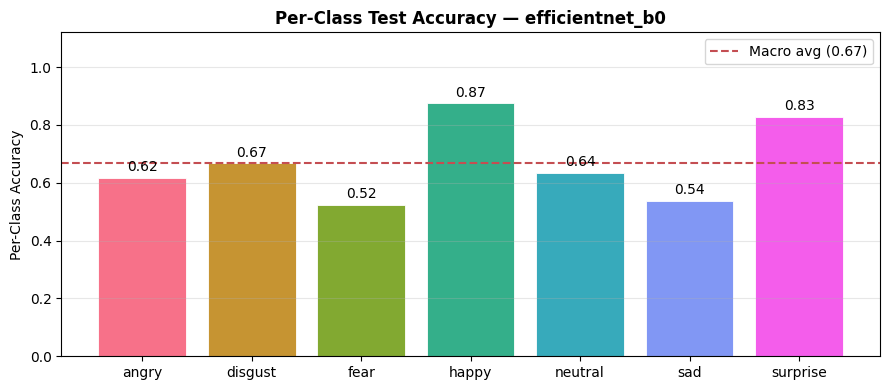

In [31]:
# ── Per-Class Accuracy ────────────────────────────────────────────────────────
per_class_acc = cm_norm.diagonal()
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CFG["classes"], per_class_acc,
              color=sns.color_palette("husl", len(CFG["classes"])),
              edgecolor="white", linewidth=0.6)
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Per-Class Accuracy")
ax.set_title(f"Per-Class Test Accuracy — {best_arch}", fontweight="bold")
ax.axhline(per_class_acc.mean(), color="#C44E52", linestyle="--",
           label=f"Macro avg ({per_class_acc.mean():.2f})")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CFG["output_dir"] / "per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Explainability with Grad-CAM

**Grad-CAM** (Selvaraju et al., 2017) uses gradients flowing into the final convolutional layer to produce a heatmap showing which image regions drove the prediction.

Green titles = correct prediction; red = misclassification.

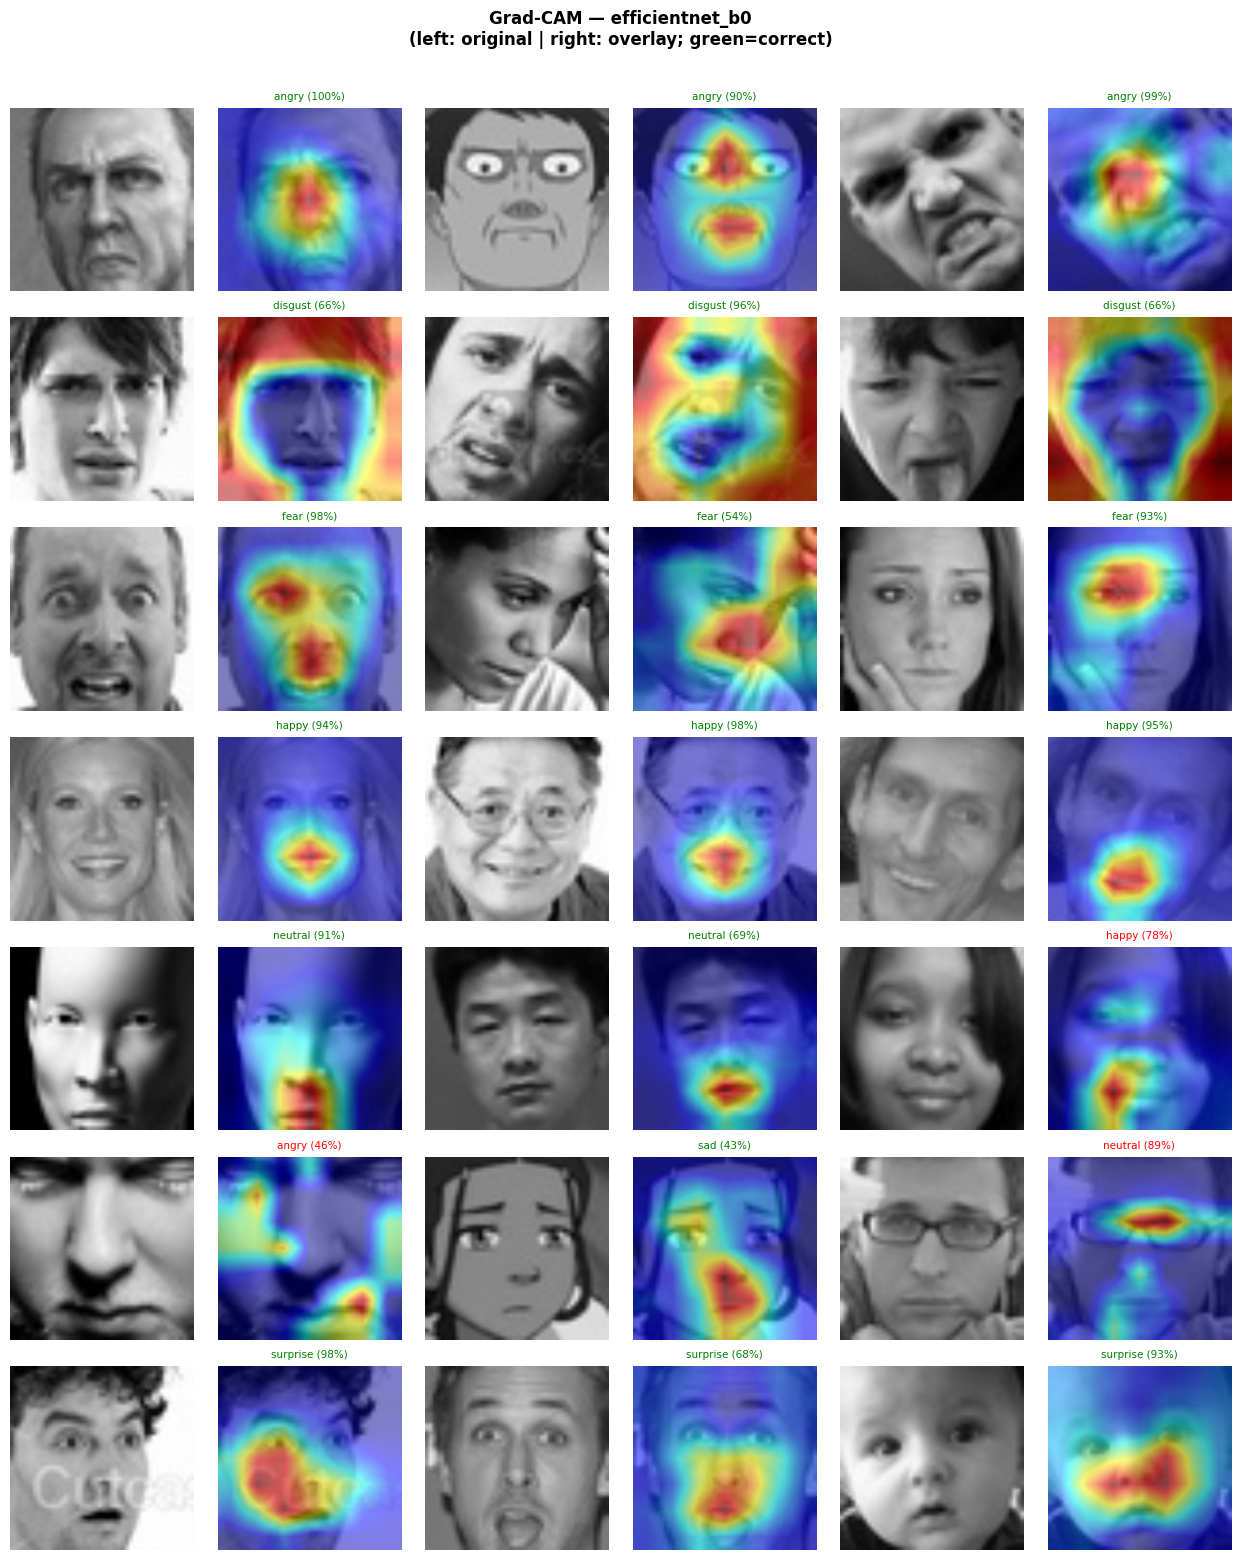

In [32]:
def tensor_to_display(tensor: torch.Tensor) -> np.ndarray:
    """Normalised CHW tensor → float32 HWC array in [0, 1]."""
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std  = torch.tensor(NORM_STD).view(3, 1, 1)
    img  = (tensor.cpu() * std + mean).permute(1, 2, 0).numpy()
    return np.clip(img, 0.0, 1.0).astype(np.float32)


def generate_gradcam_grid(
    model        : nn.Module,
    target_layer : nn.Module,
    dataset      : TransformSubset,
    n_per_class  : int = 3,
) -> None:
    """Display Grad-CAM overlays for n_per_class images per emotion class."""
    model.eval()
    cam = GradCAM(model=model, target_layers=[target_layer])

    n_cls  = len(CFG["classes"])
    n_cols = n_per_class * 2
    fig, axes = plt.subplots(n_cls, n_cols, figsize=(n_cols * 2.1, n_cls * 2.2))

    for row, cls in enumerate(CFG["classes"]):
        cls_idx  = CLASS_TO_IDX[cls]
        cls_imgs = [s for s in dataset.samples if s[1] == cls_idx]
        samples  = random.sample(cls_imgs, min(n_per_class, len(cls_imgs)))

        for col, (img_path, label) in enumerate(samples):
            img_pil = Image.open(img_path).convert("RGB")
            tensor  = eval_transforms(img_pil).unsqueeze(0).to(DEVICE)
            img_np  = tensor_to_display(tensor.squeeze(0))

            grayscale_cam = cam(input_tensor=tensor,
                                targets=[ClassifierOutputTarget(cls_idx)])[0]
            cam_overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

            with torch.no_grad():
                logits = model(tensor)
            pred_idx = int(logits.argmax(1).item())
            conf     = float(torch.softmax(logits, 1)[0, pred_idx].item())
            correct  = pred_idx == label

            ax_o = axes[row][col * 2]
            ax_o.imshow(img_np); ax_o.axis("off")
            if col == 0:
                ax_o.set_ylabel(cls, fontsize=9, fontweight="bold")

            ax_c = axes[row][col * 2 + 1]
            ax_c.imshow(cam_overlay); ax_c.axis("off")
            ax_c.set_title(f"{IDX_TO_CLASS[pred_idx]} ({conf:.0%})",
                           fontsize=7.5, color="green" if correct else "red")

    plt.suptitle(
        f"Grad-CAM — {best_arch}\n(left: original | right: overlay; green=correct)",
        fontsize=12, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.savefig(CFG["output_dir"] / "gradcam.png", dpi=130, bbox_inches="tight")
    plt.show()


generate_gradcam_grid(best_model, all_targets[best_arch], val_dataset, n_per_class=3)

## 14. Inference Pipeline

In [33]:
class FERPredictor:
    """
    Production-ready inference wrapper for a trained FER model.

    Parameters
    ----------
    model   : trained nn.Module (will be set to eval mode)
    device  : torch.device
    classes : ordered list of class names matching the training index
    """

    def __init__(self, model: nn.Module, device: torch.device,
                 classes: List[str]) -> None:
        self.model   = model.eval().to(device)
        self.device  = device
        self.classes = classes
        self._tfm    = eval_transforms

    def _to_tensor(self, image: Image.Image) -> torch.Tensor:
        return self._tfm(image.convert("RGB")).unsqueeze(0).to(self.device)

    def predict_image(
        self, image: Image.Image
    ) -> Tuple[str, float, Dict[str, float]]:
        """
        Predict the emotion in a single PIL image.

        Returns (predicted_class, confidence, class_probability_dict).
        """
        with torch.no_grad():
            probs = torch.softmax(self.model(self._to_tensor(image)), dim=1)[0].cpu().numpy()
        idx = int(probs.argmax())
        return self.classes[idx], float(probs[idx]), {c: float(p) for c, p in zip(self.classes, probs)}

    def predict_batch(self, images: List[Image.Image]) -> List[Tuple[str, float]]:
        """Batch inference for a list of PIL images."""
        batch = torch.cat([self._to_tensor(img) for img in images], dim=0)
        with torch.no_grad():
            probs = torch.softmax(self.model(batch), dim=1).cpu().numpy()
        return [(self.classes[int(p.argmax())], float(p.max())) for p in probs]

    def predict_webcam_frame(
        self, frame_bgr: np.ndarray, face_roi: Tuple[int, int, int, int]
    ) -> Tuple[str, float]:
        """
        Predict emotion for a detected face ROI in a webcam frame.

        Parameters
        ----------
        frame_bgr : full BGR frame from cv2.VideoCapture
        face_roi  : (x, y, w, h) bounding box from a face detector

        Returns (emotion_label, confidence).
        """
        x, y, w, h = face_roi
        crop = cv2.cvtColor(frame_bgr[y:y+h, x:x+w], cv2.COLOR_BGR2RGB)
        label, conf, _ = self.predict_image(Image.fromarray(crop))
        return label, conf


predictor = FERPredictor(best_model, DEVICE, CFG["classes"])
print("FERPredictor ready.")

FERPredictor ready.


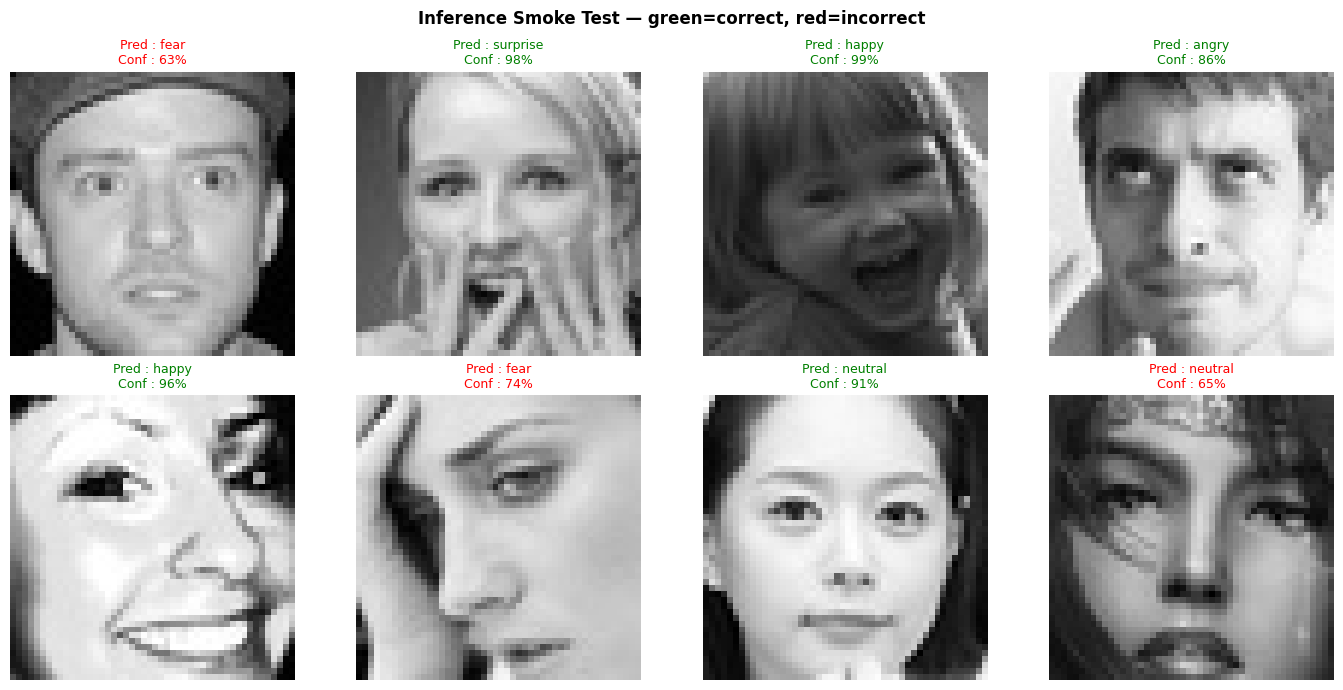

In [34]:
# ── Inference Smoke Test on Test Images ──────────────────────────────────────
smoke_samples = random.sample(test_dataset.samples, 8)
smoke_imgs    = [Image.open(p) for p, _ in smoke_samples]
smoke_labels  = [IDX_TO_CLASS[lbl] for _, lbl in smoke_samples]
smoke_preds   = predictor.predict_batch(smoke_imgs)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, (pred, conf), true in zip(axes.flat, smoke_imgs, smoke_preds, smoke_labels):
    ax.imshow(np.array(img.convert("RGB")), cmap="gray")
    colour = "green" if pred == true else "red"
    ax.set_title(f"Pred : {pred}\nConf : {conf:.0%}", fontsize=9, color=colour)
    ax.set_xlabel(f"True: {true}", fontsize=8)
    ax.axis("off")

plt.suptitle("Inference Smoke Test — green=correct, red=incorrect",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(CFG["output_dir"] / "inference_smoke_test.png", dpi=130, bbox_inches="tight")
plt.show()

## 15. Real-Time Webcam Demo

The cell below implements a full OpenCV capture loop. On a **local machine** call `run_webcam_demo(predictor)`. In **Colab**, use `demo_on_test_images()` for a static simulation.

In [35]:
FACE_CASCADE = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

EMOTION_COLORS: Dict[str, Tuple[int, int, int]] = {
    "angry"   : (0,   0,   220),
    "disgust" : (0,   140, 0),
    "fear"    : (128, 0,   128),
    "happy"   : (0,   215, 255),
    "neutral" : (200, 200, 200),
    "sad"     : (220, 100, 0),
    "surprise": (0,   165, 255),
}


def annotate_frame(
    frame      : np.ndarray,
    face_boxes : List[Tuple[int, int, int, int]],
    predictions: List[Tuple[str, float]],
) -> np.ndarray:
    """Draw bounding boxes and emotion labels onto a BGR frame copy."""
    out = frame.copy()
    for (x, y, w, h), (emotion, conf) in zip(face_boxes, predictions):
        colour = EMOTION_COLORS.get(emotion, (255, 255, 255))
        cv2.rectangle(out, (x, y), (x + w, y + h), colour, 2)
        label = f"{emotion.upper()} {conf:.0%}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(out, (x, y - th - 10), (x + tw + 6, y), colour, -1)
        cv2.putText(out, label, (x + 3, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    return out


def run_webcam_demo(predictor: FERPredictor, duration_s: int = 30) -> None:
    """Real-time FER on webcam (requires physical webcam — not available in Colab)."""
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("ERROR: Could not open webcam.")
        return
    t_start = time.time()
    while time.time() - t_start < duration_s:
        ret, frame = cap.read()
        if not ret:
            break
        gray     = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        detected = FACE_CASCADE.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(48, 48)
        )
        faces = [tuple(f) for f in detected] if len(detected) > 0 else []
        preds = [predictor.predict_webcam_frame(frame, roi) for roi in faces]
        cv2.imshow("FER — Real-Time Demo  [Q to quit]", annotate_frame(frame, faces, preds))
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    cap.release()
    cv2.destroyAllWindows()
    print("Webcam demo finished.")


print("run_webcam_demo(predictor) — call on a local machine with a webcam.")

run_webcam_demo(predictor) — call on a local machine with a webcam.


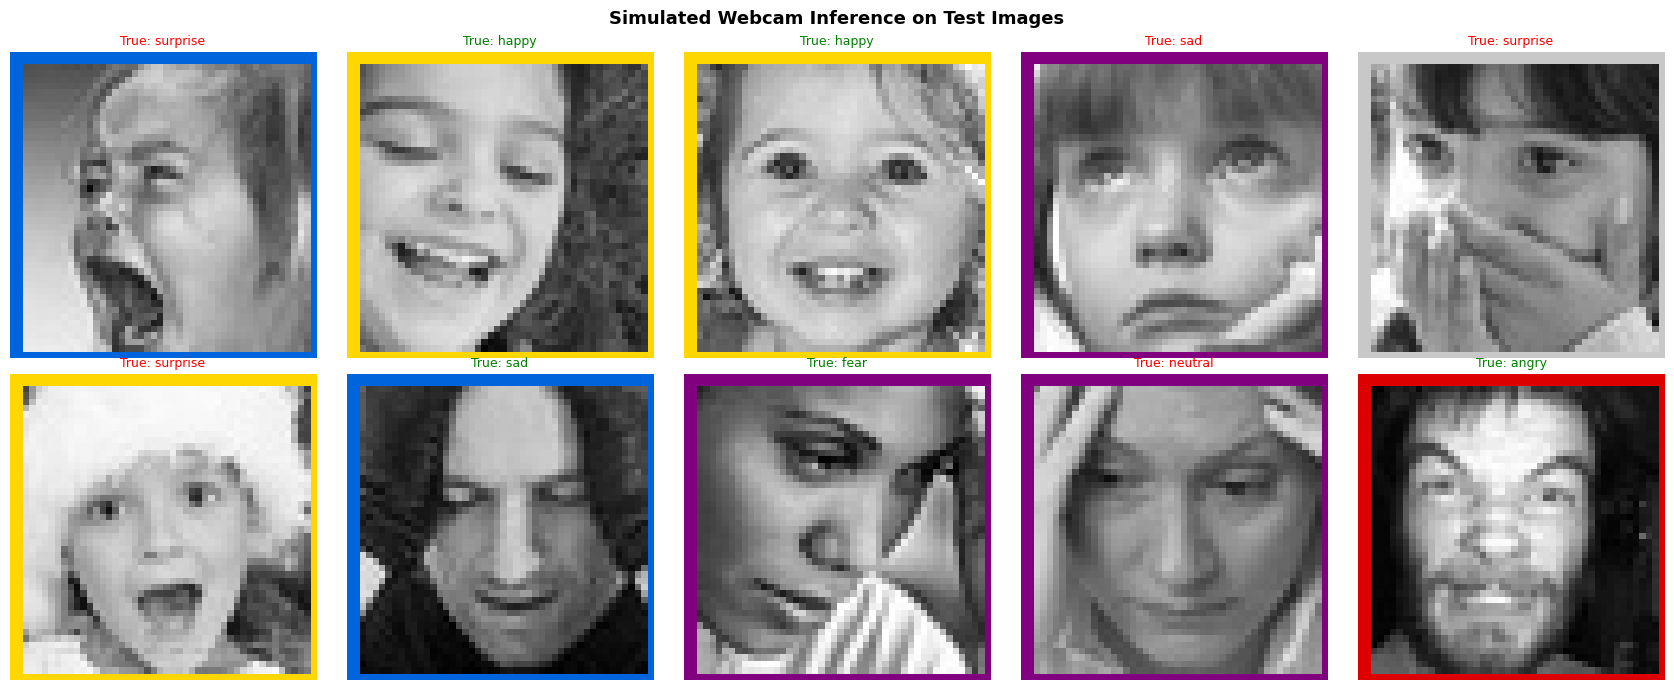

In [36]:
# ── Colab-Compatible Static Simulation ────────────────────────────────────────
def demo_on_test_images(predictor: FERPredictor, n: int = 10) -> None:
    """Simulate the full webcam pipeline on saved test images."""
    samples = random.sample(test_dataset.samples, n)
    fig, axes = plt.subplots(2, 5, figsize=(17, 7))
    for ax, (img_path, lbl) in zip(axes.flat, samples):
        frame_bgr = cv2.imread(str(img_path))
        if frame_bgr is None:
            ax.axis("off"); continue
        h, w    = frame_bgr.shape[:2]
        roi     = (0, 0, w, h)
        pred, conf = predictor.predict_webcam_frame(frame_bgr, roi)
        annotated  = annotate_frame(frame_bgr, [roi], [(pred, conf)])
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        colour = "green" if pred == IDX_TO_CLASS[lbl] else "red"
        ax.set_title(f"True: {IDX_TO_CLASS[lbl]}", fontsize=9, color=colour)
        ax.axis("off")
    plt.suptitle("Simulated Webcam Inference on Test Images",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(CFG["output_dir"] / "webcam_simulation.png", dpi=130, bbox_inches="tight")
    plt.show()


demo_on_test_images(predictor, n=10)

## 16. Model Export & Loading

In [37]:
best_model_path = CFG["output_dir"] / "best_model.pth"

torch.save(
    {
        "arch"         : best_arch,
        "state_dict"   : best_model.state_dict(),
        "class_to_idx" : CLASS_TO_IDX,
        "val_metrics"  : all_val_metrics[best_arch],
        "test_metrics" : test_metrics,
        "norm_mean"    : NORM_MEAN,
        "norm_std"     : NORM_STD,
        "img_size"     : CFG["img_size"],
    },
    best_model_path,
)

size_mb = best_model_path.stat().st_size / 1_000_000
print(f"Checkpoint saved : {best_model_path}")
print(f"File size        : {size_mb:.1f} MB")

Checkpoint saved : /content/outputs/best_model.pth
File size        : 16.4 MB


In [38]:
def load_fer_model(
    checkpoint_path: str | Path,
    device         : torch.device = DEVICE,
) -> Tuple[nn.Module, Dict]:
    """
    Load a saved FER checkpoint and reconstruct the model.

    Returns (model_in_eval_mode, checkpoint_dict).
    """
    ckpt  = torch.load(checkpoint_path, map_location=device)
    arch  = ckpt["arch"]
    n_cls = len(ckpt["class_to_idx"])

    model, _ = build_transfer_model(arch, num_classes=n_cls)
    model.load_state_dict(ckpt["state_dict"])
    model = model.to(device).eval()

    print(f"Loaded '{arch}' from {checkpoint_path}")
    print(f"Val  metrics : {ckpt.get('val_metrics', 'n/a')}")
    print(f"Test metrics : {ckpt.get('test_metrics', 'n/a')}")
    return model, ckpt


loaded_model, loaded_ckpt = load_fer_model(best_model_path)
_, rt_acc, _, _ = evaluate(loaded_model, test_loader, criterion_tl)
print(f"Round-trip test accuracy : {rt_acc:.4f}")

efficientnet_b0 — trainable: 645,507 / total: 4,016,515
Loaded 'efficientnet_b0' from /content/outputs/best_model.pth
Val  metrics : {'accuracy': 0.6882076293328688, 'precision': 0.6878948031332018, 'recall': 0.6685068147367023, 'f1': 0.6766462938114539}
Test metrics : {'accuracy': 0.6816662022847589, 'precision': 0.6722016682307387, 'recall': 0.6687934194293772, 'f1': 0.670196812884768}
Round-trip test accuracy : 0.6817


## 17. Portfolio Results Summary

---

### Data Split Architecture
```
fer2013/train/  (28,709 images)
  ├── train subset  80%  (≈22,967) — gradient updates + augmentation
  └── val   subset  20%  (≈5,742)  — early stopping, LR scheduling, model selection

fer2013/test/   (3,589 images)      — evaluated ONCE at the very end
```
This is the correct way to use FER2013. Using the test set during training (even just for monitoring) constitutes data leakage that inflates reported performance.

---

### Design Decisions
| Component | Choice | Justification |
|-----------|--------|---------------|
| Val split | 20% stratified from train/ | Preserves class proportions; keeps test set clean |
| Baseline loss | Plain CrossEntropyLoss | Label smoothing floor (≈1.94) caused loss to get stuck |
| TL loss | CrossEntropy + smoothing=0.05 | Mild smoothing improves minority-class calibration |
| Sampler cap | 2× majority class | Prevents 66× over-repetition of `disgust` images |
| Early stopping | Patience 8 (baseline) / 5 (TL) | Shallow CNNs need more epochs; TL converges faster |
| LR baseline | ReduceLROnPlateau (patience=5, min_lr=1e-5) | Prevents LR collapse before the model learns |
| LR TL phase 2 | CosineAnnealingLR | Smooth decay prevents loss-of-plasticity |

---

### Lessons Learned
1. **Always separate val and test sets** — using the test set for early stopping or LR scheduling is data leakage, even if it's just monitoring.
2. **Label smoothing and class imbalance interact badly** — the smoothed CE floor masked the loss signal entirely for the baseline.
3. **WeightedRandomSampler needs a cap** — uncapped oversampling causes the model to memorise the few minority-class images rather than learn features.
4. **Grad-CAM validates semantic correctness** — confirming the model attends to the right facial regions is as important as the accuracy number.

---

### Future Work
| Direction | Expected Benefit |
|-----------|-----------------|
| Vision Transformer (ViT-B/16) | Global attention for subtle expression cues |
| Semi-supervised learning | Leverage large unlabelled web face datasets |
| Multi-task (AU detection) | Richer supervision improves minority class recall |
| ONNX / TorchScript export | Edge deployment on mobile / embedded devices |
| Fairness audit | Per-demographic accuracy evaluation |

---
*Notebook developed as part of an MSc Computer Vision portfolio project.*

In [39]:
# ── Final Results Printout ────────────────────────────────────────────────────
SEP = "=" * 70
print(SEP)
print("  FACIAL EXPRESSION RECOGNITION — FINAL RESULTS")
print("  (val metrics used for selection | test metrics are the honest numbers)")
print(SEP)
header = f"  {'Model':<22s} {'Val F1':>8s} {'Test Acc':>10s} {'Test F1':>8s}"
print(header)
print("-" * 70)

for name in ["BaselineCNN"] + ARCHITECTURES:
    vm = all_val_metrics[name]
    tm = test_metrics if name == best_arch else all_val_metrics[name]  # only best has test
    note = " ← SELECTED" if name == best_arch else ""
    print(f"  {name:<22s} {vm['f1']:>8.4f} {tm.get('accuracy', float('nan')):>10.4f}"
          f" {tm.get('f1', float('nan')):>8.4f}{note}")

print(SEP)
print(f"  Best model  : {best_arch}")
print(f"  Checkpoint  : {best_model_path}")
print(f"  Output dir  : {CFG['output_dir']}")
print(SEP)

  FACIAL EXPRESSION RECOGNITION — FINAL RESULTS
  (val metrics used for selection | test metrics are the honest numbers)
  Model                    Val F1   Test Acc  Test F1
----------------------------------------------------------------------
  BaselineCNN              0.4520     0.5177   0.4520
  resnet50                 0.6709     0.6816   0.6709
  efficientnet_b0          0.6766     0.6817   0.6702 ← SELECTED
  Best model  : efficientnet_b0
  Checkpoint  : /content/outputs/best_model.pth
  Output dir  : /content/outputs
